# E51 · Designing a thermal gradient plate: Bayesian calibration and optimal placement of heaters, insulation and sensors for the 2-D heat equation

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Simulated: a 40 × 20 cm metal plate governed by the 2-D steady heat equation, a calibration experiment with three test heaters and twelve thermocouples, and operating disturbances (room temperature drift, air currents, heater ageing) |
| **You will learn** | The **2-D steady heat equation** with conduction, face and edge losses and heat sources, discretised by **finite volumes** into a linear system $A(\theta)\,T = q$ · the superposition principle: the temperature field is **linear in heater powers**, so each heater has an influence map · **Bayesian calibration** of conductivity, heat-transfer coefficients and heater efficiency with the PDE solved inside PyMC (`pt.linalg.solve`), and what the experiment leaves unidentified · **design under uncertainty**: choosing heater sites and powers by expected error over the posterior (greedy search with constrained least squares) with heaters kept out of the working area, and when a plug-in design is enough · **insulation** as passive robustness to drafts · **sensor placement for feedback control**: a Bayesian estimator of the disturbances, a controller that re-optimises powers, and greedy placement against Monte Carlo closed-loop error, compared with even spacing, sensors on the heaters and an oracle · **power headroom** as a design requirement |

## The problem, in one paragraph

Many instruments need a surface held at a precise **temperature gradient** rather than a single
temperature: gradient plates for testing seed germination or bacterial growth at many
temperatures at once, gradient PCR blocks, directional solidification of alloys and crystals,
thermophoresis cells. The engineer controls where heat goes in (heating elements), where it
is kept in (insulation) and where it is measured (sensors that feed a controller). Heat does
the rest by spreading through the plate and leaking to the room, according to the heat
equation. The difficulty is that the plate's properties are only approximately known, and the
room does not stay the same. Here we design such a plate: a 40 × 20 cm metal plate whose
central working area must run from **30 °C at the left to 70 °C at the right**, uniformly across
its width, in a 20 °C room. We learn the plate's physics from a short calibration experiment,
then choose heaters, insulation and sensors to hit the gradient in *all plausible* versions of
the plate and the room, not just the most likely one.

## The plan

1. The heat equation on a plate, as a linear system
2. Calibration: learning the plate's physics
3. Where to put the heaters, and how hard to drive them
4. Insulation: passive robustness
5. Sensors and feedback: holding the gradient when the room changes
6. The final design

In [1]:
import logging
import time

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import pytensor.tensor as pt
from matplotlib.patches import Rectangle
from scipy.optimize import lsq_linear

RANDOM_SEED = 51
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)
BLUE, ORANGE, AQUA, GREY, PURPLE, RED, INK = (
    "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8c5ac8", "#c8384e", "#222222")
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")

PyMC 6.3.2, ArviZ 1.3.0


## 1 · The heat equation on a plate, as a linear system

A thin plate of thickness $\delta$ and conductivity $k$ conducts heat in its plane and loses heat
to the room through its two faces (heat-transfer coefficient $h$, W m⁻² K⁻¹) and its edges
($h_e$). Heaters add power density $q(x, y)$, of which a fraction $\eta$ reaches the plate. At
steady state, with $u = T - T_{\text{room}}$,

$$k\,\delta\,\nabla^2 u \;-\; (h_{\text{front}} + h_{\text{back}}(x, y))\,u \;+\; \eta\,q \;=\; 0,$$

plus $-k\,\partial_n u = h_e\,u$ on the edges. We split the plate into 24 × 12 square cells of
1.67 cm and write the heat balance of each cell (a **finite-volume** discretisation): conduction
to its four neighbours, loss through its faces and any edges, and the heater power it receives.
The result is a linear system

$$A(\theta)\,u = \eta\,q, \qquad A(\theta) = -k\,\delta\,L + \mathrm{diag}\big(h\,(1 + m_{\text{back}})\,\Delta x^2
  + h_e\,\delta\,\Delta x\,n_{\text{edge}}\big),$$

where $L$ is the graph Laplacian of the grid, $m_{\text{back}}$ is 1 on bare back face and 0.1
under insulation, and $n_{\text{edge}}$ counts a cell's outer edges. Two consequences shape the
whole design:

- **Superposition.** $u$ is linear in the heater powers: $u = \sum_i p_i\,g_i(\theta)$, where
  $g_i$ is heater $i$'s **influence map** (the temperature rise per watt). Choosing powers is a
  linear least-squares problem.
- **A heat-spreading length.** Heat conducted in the plane competes with heat lost through the
  faces over a distance $\ell = \sqrt{k\delta / 2h}$, about 13 cm here. A single heater warms
  a region of about that size and no more, so a smooth gradient over 30 cm needs several
  heaters, each doing part of the job.

We take a brass-like plate: $\delta = 5$ mm, and "true" values $k = 60$ W m⁻¹ K⁻¹, $h = 9$,
$h_e = 15$ W m⁻² K⁻¹, $\eta = 0.93$ (the truth is unknown to the designer).

heat-spreading length sqrt(k delta / 2h) = 12.9 cm


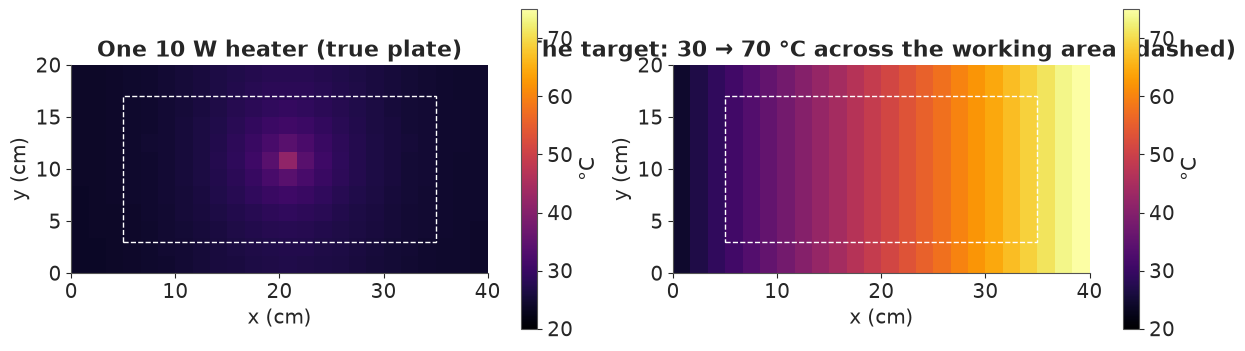

In [2]:
LX, LY, NX, NY = 0.40, 0.20, 24, 12
DX = LX / NX
DELTA, T_ROOM = 0.005, 20.0
xc, yc = (np.arange(NX) + 0.5) * DX, (np.arange(NY) + 0.5) * DX
X, Y = np.meshgrid(xc, yc, indexing="xy")
N = NX * NY


def cell(i, j):
    return j * NX + i


LAP = np.zeros((N, N))
N_EDGE = np.zeros(N)
for j in range(NY):
    for i in range(NX):
        a = cell(i, j)
        for di, dj in [(1, 0), (-1, 0), (0, 1), (0, -1)]:
            if 0 <= i + di < NX and 0 <= j + dj < NY:
                LAP[a, a] -= 1
                LAP[a, cell(i + di, j + dj)] += 1
            else:
                N_EDGE[a] += 1


def operator(k, h, h_edge, back=None, h_factor=None):
    """A(theta): conduction + face loss (h_factor: spatial multiplier for drafts) + edge loss."""
    back = np.ones(N) if back is None else back
    hf = np.ones(N) if h_factor is None else h_factor
    return -k * DELTA * LAP + np.diag(h * hf * (1 + back) * DX**2 + h_edge * DELTA * DX * N_EDGE)


def influence(theta, sites, back=None, h_factor=None, eff=None):
    """Temperature rise (K) per watt for heaters at the given cells: (N, n_sites)."""
    q = np.zeros((N, len(sites)))
    q[sites, np.arange(len(sites))] = theta["eta"] * (1.0 if eff is None else eff)
    return np.linalg.solve(operator(theta["k"], theta["h"], theta["h_edge"], back, h_factor), q)


THETA_TRUE = dict(k=60.0, h=9.0, h_edge=15.0, eta=0.93)
WORK = ((X >= 0.05) & (X <= 0.35) & (Y >= 0.03) & (Y <= 0.17)).ravel()   # working area
T_TARGET = (30 + 40 * (X - 0.05) / 0.30).ravel()
ell = np.sqrt(THETA_TRUE["k"] * DELTA / (2 * THETA_TRUE["h"]))
print(f"heat-spreading length sqrt(k delta / 2h) = {100 * ell:.1f} cm")


def show_field(ax, field, title, vmin=20, vmax=75, cmap="inferno"):
    im = ax.imshow(field.reshape(NY, NX), origin="lower", extent=[0, 100 * LX, 0, 100 * LY],
                   vmin=vmin, vmax=vmax, cmap=cmap, aspect="equal")
    ax.add_patch(Rectangle((5, 3), 30, 14, fill=False, ec="white", lw=1, ls="--"))
    ax.set(title=title, xlabel="x (cm)", ylabel="y (cm)")
    return im


demo_site = [cell(12, 6)]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
im = show_field(axes[0], T_ROOM + 10 * influence(THETA_TRUE, demo_site)[:, 0], "One 10 W heater (true plate)")
fig.colorbar(im, ax=axes[0], label="°C")
im = show_field(axes[1], T_TARGET, "The target: 30 → 70 °C across the working area (dashed)")
fig.colorbar(im, ax=axes[1], label="°C");

One 10 W heater warms a patch about 10-15 cm across by a few degrees: heat does not travel
far before it leaks out of the faces. The target (right) is a ramp in $x$, flat in $y$, over the
dashed working area; outside it the temperature is free.

## 2 · Calibration: learning the plate's physics

The designer does not know $k$, $h$, $h_e$ or $\eta$ exactly. A calibration experiment: three
runs, each with one 10 W test heater at a different place, and twelve thermocouples (±0.2 °C)
glued at random positions. The model solves the discretised heat equation for each run inside
PyMC (`pt.linalg.solve` on the 288 × 288 system, gradients included). Priors are
order-of-magnitude: $k \sim$ LogNormal(log 50, 0.5) (brass or aluminium alloys), $h \sim$
LogNormal(log 10, 0.5) (natural convection plus radiation), $h_e \sim$ LogNormal(log 10, 0.7),
$\eta \sim$ Beta(40, 4) (most of the electrical power reaches the plate).

In [3]:
cal_rng = np.random.default_rng(0)
test_sites = [cell(int(x / DX), int(y / DX)) for x, y in [(0.06, 0.10), (0.20, 0.05), (0.33, 0.14)]]
thermocouples = cal_rng.choice(N, 12, replace=False)
Q_test = np.zeros((3, N))
Q_test[np.arange(3), test_sites] = 10.0
T_cal_true = T_ROOM + np.linalg.solve(operator(THETA_TRUE["k"], THETA_TRUE["h"], THETA_TRUE["h_edge"]),
                                      THETA_TRUE["eta"] * Q_test.T).T[:, thermocouples]
T_cal = T_cal_true + 0.2 * cal_rng.standard_normal(T_cal_true.shape)

lap_t, edge_t = pt.as_tensor(LAP), pt.as_tensor(N_EDGE)
with pm.Model() as calibration:
    k = pm.LogNormal("k", np.log(50), 0.5)
    h = pm.LogNormal("h", np.log(10), 0.5)
    h_edge = pm.LogNormal("h_edge", np.log(10), 0.7)
    eta = pm.Beta("eta", 40, 4)
    sigma = pm.HalfNormal("sigma", 0.5)
    A = -k * DELTA * lap_t + pt.diag(2 * h * DX**2 + h_edge * DELTA * DX * edge_t)
    u = pt.linalg.solve(A, eta * Q_test.T).T                     # (runs, cells)
    pm.Normal("T_obs", T_ROOM + u[:, thermocouples], sigma, observed=T_cal)

t0 = time.time()
with calibration:
    idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False, target_accept=0.9)
print(f"{time.time() - t0:.0f} s, {int(idata.sample_stats['diverging'].sum())} divergences")
summ = az.summary(idata, var_names=["k", "h", "h_edge", "eta", "sigma"], round_to=3)
summ["truth"] = [*THETA_TRUE.values(), 0.2]
print(summ[["mean", "sd", "eti89_lb", "eti89_ub", "ess_bulk", "r_hat", "truth"]])
post = idata.posterior.to_dataset().stack(sample=("chain", "draw"))
draw_idx = rng.choice(post.sizes["sample"], 200, replace=False)
THETA_DRAWS = [{v: float(post[v].values[i]) for v in ["k", "h", "h_edge", "eta"]} for i in draw_idx]
THETA_MEAN = {v: float(post[v].mean()) for v in ["k", "h", "h_edge", "eta"]}
print("correlations:", {f"{a}-{b}": round(float(np.corrcoef(post[a], post[b])[0, 1]), 2)
                        for a, b in [("k", "h"), ("k", "eta"), ("h", "eta")]})

18 s, 2 divergences
          mean     sd  eti89_lb  eti89_ub  ess_bulk  r_hat  truth
k       59.288  2.820    54.443    63.176   492.765  1.006  60.00
h        9.074  0.441     8.324     9.678   479.551  1.007   9.00
h_edge   6.774  3.511     2.355    13.295  1761.141  1.000  15.00
eta      0.912  0.042     0.839     0.967   453.637  1.007   0.93
sigma    0.189  0.023     0.156     0.230  2365.338  1.002   0.20
correlations: {'k-h': 0.91, 'k-eta': 0.96, 'h-eta': 0.95}


Three heaters and twelve thermocouples pin down the conductivity, the face coefficient and the
heater efficiency to within about 4-5%, and their 89% intervals contain the true values. The
three are strongly correlated (0.89-0.95, printout): thermocouples measure temperature *rises*,
which depend on ratios like $\eta/k$ and $\eta/h$, so a less efficient heater on a less
conductive, less leaky plate looks almost the same. The **edge coefficient** is barely learned:
only a few thermocouples sit near an edge, and edges carry a small share of the heat. Its
posterior is mostly prior, pulled towards the prior median of 10, and its 89% interval
(about 2-13) **misses the true value of 15**. A weakly identified parameter plus a prior centred
in the wrong place is how honest-looking intervals go wrong; the design will have to be robust
to the edges, or a second experiment should put thermocouples near them.

## 3 · Where to put the heaters, and how hard to drive them

Heater sites are chosen from a 12 × 6 lattice of 72 candidate positions. For a given set of
sites, the powers minimise the **expected** squared error over the working area across posterior
draws,

$$\min_{0 \le p_i \le p_{\max}}\; \mathbb{E}_{\theta \mid \text{calibration}}\,
  \big\lVert u_{\text{target}} - G(\theta)\,p \big\rVert^2_{\text{work}},$$

a constrained least-squares problem once the influence maps $G(\theta)$ of the candidate sites
are stacked over 60 posterior draws (`scipy.optimize.lsq_linear`). The sites are added
**greedily**: at each step, try every remaining candidate and keep the one that reduces the
expected error most. Heaters may go anywhere **in the frame around the working area** (the
144 cells outside the dashed rectangle), not inside it: the working area is where the samples
sit, and a heater there makes a local hot spot. (A first version of this notebook allowed
heaters everywhere; the search put two inside the working area and the worst cells ended up
10 °C off target.) The heaters are rated at 20 W, but the nominal design may use at most 14 W
per heater: **headroom** for the controller in section 5.

In [4]:
CANDIDATES = np.flatnonzero(~WORK)                                           # heaters stay in the frame
P_RATED, P_NOMINAL = 20.0, 14.0
design_draws = THETA_DRAWS[:60]
G_all = np.array([influence(th, CANDIDATES) for th in design_draws])        # (draws, N, 72)
G_plug = influence(THETA_MEAN, CANDIDATES)[None]                             # posterior mean only
u_target = (T_TARGET - T_ROOM)[WORK]


def fit_powers(G_stack, chosen, cap=P_NOMINAL):
    A = np.concatenate([g[WORK][:, chosen] for g in G_stack])
    b = np.tile(u_target, len(G_stack))
    return lsq_linear(A, b, bounds=(0, cap)).x


def expected_rms(G_stack, chosen, p):
    err = np.array([g[WORK][:, chosen] @ p - u_target for g in G_stack])
    return np.sqrt(np.mean(err**2))


def greedy_heaters(G_stack, n_heaters):
    chosen, path = [], []
    for _ in range(n_heaters):
        scores = [(expected_rms(G_stack, chosen + [c], fit_powers(G_stack, chosen + [c])), c)
                  for c in range(len(CANDIDATES)) if c not in chosen]
        best = min(scores)
        chosen.append(best[1])
        path.append(best[0])
    return chosen, path


t0 = time.time()
heaters, path = greedy_heaters(G_all, 8)
print(f"greedy search: {time.time() - t0:.0f} s; expected RMS error (°C) with 1..8 heaters:", np.round(path, 2))
N_HEAT = 6
sites = heaters[:N_HEAT]
p_design = fit_powers(G_all, sites)

# Alternatives for comparison, all evaluated over the SAME posterior draws
edge_rows = [c for c in range(len(CANDIDATES)) if CANDIDATES[c] // NX in (0, NY - 1)]
midline = [min(edge_rows, key=lambda c: abs(xc[CANDIDATES[c] % NX] - x0) + 10 * abs(CANDIDATES[c] // NX - row))
           for row in (0, NY - 1) for x0 in (0.15, 0.25, 0.35)]                 # 3 evenly along each long edge
p_midline = fit_powers(G_all, midline)
plug_sites, _ = greedy_heaters(G_plug, N_HEAT)
p_plug = fit_powers(G_plug, plug_sites)
eval_draws = np.array([influence(th, CANDIDATES) for th in THETA_DRAWS[60:200]])  # held-out draws
for name, s_, p_ in [("greedy, posterior", sites, p_design), ("evenly along the long edges", midline, p_midline),
                     ("greedy, plug-in (posterior mean)", plug_sites, p_plug)]:
    errs = np.array([np.sqrt(np.mean((g[WORK][:, s_] @ p_ - u_target) ** 2)) for g in eval_draws])
    print(f"{name:<34} powers {np.round(p_, 1)} (total {p_.sum():.0f} W); RMS error over 140 other "
          f"posterior draws: median {np.median(errs):.2f}, 90th pct {np.quantile(errs, 0.9):.2f} °C")

greedy search: 3 s; expected RMS error (°C) with 1..8 heaters: [23.09 13.92  5.75  2.21  1.7   1.43  1.39  1.35]


greedy, posterior                  powers [ 9.8  9.2  6.6  6.1  5.7 14. ] (total 51 W); RMS error over 140 other posterior draws: median 1.43, 90th pct 1.45 °C
evenly along the long edges        powers [ 1.7 10.3 14.   1.7 10.3 14. ] (total 52 W); RMS error over 140 other posterior draws: median 2.00, 90th pct 2.02 °C
greedy, plug-in (posterior mean)   powers [ 9.2  9.8  6.6  6.1  5.7 14. ] (total 51 W); RMS error over 140 other posterior draws: median 1.43, 90th pct 1.46 °C


**Heater count.** The expected error falls quickly with the first four heaters and flattens after
six (printout); we use six. **Placement matters**: six heaters spaced evenly along the two long
edges ("evenly" in the printout) give an RMS error of about 2.0 °C against 1.4 °C for the greedy
layout, which puts most of its heat at the hot end, where the plate must be hottest, and adds
smaller heaters along the edges halfway down.

**Plug-in versus posterior design.** Designing against the posterior-mean plate alone gives the
*same* heater sites and nearly the same powers here, and the same error over 140 held-out
posterior draws. That is a result, not a rule: the parameters the design depends on
(conductivity, face loss, efficiency) are well determined as a group, and the poorly known edge
coefficient matters little for the working area. The posterior still earns its keep: it says the
error is 1.4-1.5 °C in almost every plausible plate, which the plug-in design alone cannot
tell you, and it is what the controller in section 5 uses.

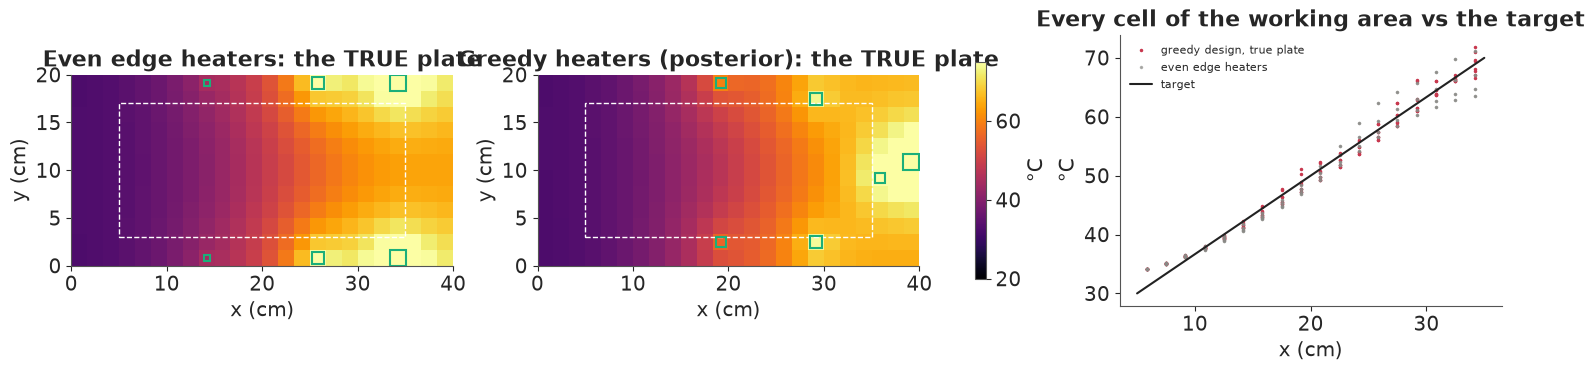

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, (name, s_, p_) in zip(axes, [("Even edge heaters", midline, p_midline),
                                      ("Greedy heaters (posterior)", sites, p_design)]):
    field = T_ROOM + influence(THETA_TRUE, CANDIDATES[s_]) @ p_
    im = show_field(ax, field, f"{name}: the TRUE plate")
    for c, pw in zip(CANDIDATES[s_], p_):
        ax.plot(100 * xc[c % NX], 100 * yc[c // NX], "s", ms=4 + pw / 2, mfc="none", mec=AQUA, mew=1.5)
fig.colorbar(im, ax=axes[:2], label="°C", shrink=0.8)
ax = axes[2]
field = T_ROOM + influence(THETA_TRUE, CANDIDATES[sites]) @ p_design
work_x = X.ravel()[WORK]
ax.plot(100 * work_x, field[WORK], ".", ms=3, color=RED, label="greedy design, true plate")
field_mid = T_ROOM + influence(THETA_TRUE, CANDIDATES[midline]) @ p_midline
ax.plot(100 * work_x, field_mid[WORK], ".", ms=3, color=GREY, alpha=0.6, label="even edge heaters")
ax.plot([5, 35], [30, 70], color=INK, lw=1.5, label="target")
ax.set(xlabel="x (cm)", ylabel="°C", title="Every cell of the working area vs the target")
ax.legend(fontsize=8);

Squares mark the heaters (size = power). On the true plate the greedy design gives a ramp
whose cells mostly sit within a degree or two of the target (right panel). The even edge
heaters run too hot next to each heater and too cool between them along the middle. Neither
design can reach the target at the cold end: the left column of the working area runs 2-4 °C
too warm, because heat conducted from the right cannot be removed there - only a cooler (a heat
sink at the left edge) could fix that.

## 4 · Insulation: passive robustness

In operation the room changes. We model three kinds of **disturbance**, drawn independently for
each scenario: the room temperature drifts ($\pm 2$ °C, sd), air currents change the face
coefficient on the left and right halves of the plate independently (log-normal, sd 25%), and
each heater's efficiency ages (sd 10%). Combined with the posterior of the plate's physics, this
gives 120 plausible operating conditions.

Insulation acts before any controller: a pad on the back face cuts the loss there (to 10% of the
bare value), so the plate depends less on drafts. We offer six vertical strips (6.7 cm wide) as
candidates, choose up to two greedily by the expected error **with the heater powers
re-optimised for each insulation choice but without feedback**, and record the power needed.

In [6]:
N_SCEN = 120
dist_rng = np.random.default_rng(5)
scen_theta = [THETA_DRAWS[i] for i in dist_rng.integers(len(THETA_DRAWS), size=N_SCEN)]
room_shift = dist_rng.normal(0, 2.0, N_SCEN)
draft_left, draft_right = np.exp(dist_rng.normal(0, 0.25, (2, N_SCEN)))
heater_age = np.exp(dist_rng.normal(0, 0.10, (N_SCEN, N_HEAT)))
LEFT = (X < LX / 2).ravel()
sensor_noise = 0.2 * dist_rng.standard_normal((N_SCEN, N))      # common random numbers
STRIPS = [(i0 * DX, (i0 + 4) * DX) for i0 in range(0, NX, 4)]


def back_mask(chosen_strips):
    m = np.ones(N)
    for s_ in chosen_strips:
        m[((X >= STRIPS[s_][0]) & (X < STRIPS[s_][1])).ravel()] = 0.1
    return m


def scenario_influences(back):
    return np.array([influence(th, CANDIDATES[sites], back, np.where(LEFT, dl, dr), age)
                     for th, dl, dr, age in zip(scen_theta, draft_left, draft_right, heater_age)])


def open_loop(back):
    """Re-optimise nominal powers for this insulation (no disturbances), then face the scenarios."""
    G_design = np.array([influence(th, CANDIDATES[sites], back) for th in design_draws[:30]])
    A = np.concatenate([g[WORK] for g in G_design])
    p = lsq_linear(A, np.tile(u_target, len(G_design)), bounds=(0, P_NOMINAL)).x
    G_s = scenario_influences(back)
    fields = T_ROOM + room_shift[:, None] + G_s @ p
    return p, G_s, fields


def rms_work(fields):
    return float(np.sqrt(np.mean((fields[:, WORK] - T_TARGET[WORK]) ** 2)))


t0 = time.time()
insulation_results = {}
chosen_strips = []
p_bare, G_bare, f_bare = open_loop(back_mask([]))
insulation_results["none"] = (rms_work(f_bare), p_bare.sum())
for _ in range(2):
    trials = []
    for s_ in range(len(STRIPS)):
        if s_ in chosen_strips:
            continue
        p_, _, f_ = open_loop(back_mask(chosen_strips + [s_]))
        trials.append((rms_work(f_), p_.sum(), s_))
    best = min(trials)
    chosen_strips.append(best[2])
    insulation_results[str([f"{100 * STRIPS[s][0]:.0f}-{100 * STRIPS[s][1]:.0f} cm" for s in chosen_strips])] = best[:2]
print(f"({time.time() - t0:.0f} s)")
for name, (e, pw) in insulation_results.items():
    print(f"insulation {name:<30} open-loop RMS error under disturbances {e:.2f} °C, nominal power {pw:.0f} W")

(1 s)
insulation none                           open-loop RMS error under disturbances 7.15 °C, nominal power 51 W
insulation ['27-33 cm']                   open-loop RMS error under disturbances 6.87 °C, nominal power 46 W
insulation ['27-33 cm', '33-40 cm']       open-loop RMS error under disturbances 6.55 °C, nominal power 40 W


Without feedback the disturbances dominate: a perfectly tuned open-loop plate is about 7 °C RMS
off target, mostly because the room temperature shifts the whole plate and drafts change how
much heat each region loses. The greedy choice insulates the **hot end** (the strips from 27 to
40 cm), where the plate is hottest above the room and loses most heat. That saves about a fifth
of the heater power (51 → 40 W) and makes that end less sensitive to drafts, reducing the
open-loop error a little (7.2 → 6.6 °C). Insulation cannot follow a room that is warmer or colder
than planned: that is the job of sensors and feedback.

## 5 · Sensors and feedback: holding the gradient when the room changes

A controller reads a few thermocouples and resets the heater powers. Ours is a **Bayesian
certainty-equivalence** controller:

1. **Estimate** the disturbances $d$ = (room shift, log draft left, log draft right, log age of
   each heater) from the sensor readings with a linear-Gaussian update: prior $d \sim
   N(0, \Sigma_d)$ with the scales above, sensitivities $J = \partial T_{\text{sensors}}/\partial d$
   from the posterior-mean model, and a noise covariance that includes both the ±0.2 °C sensor
   noise and the **posterior uncertainty of the plate's physics** at the sensor positions.
2. **Re-optimise** the heater powers for the model with the estimated disturbances, now allowed
   up to the full 20 W rating.

Then evaluate the true field in each scenario. The sensor positions are chosen **greedily** from
72 candidate positions by the Monte Carlo closed-loop error, and compared with: five sensors
evenly spaced on the midline, sensors on (next to) the heaters, and an **oracle** that knows each
scenario's disturbances and physics exactly (the best any sensor layout could do with these
heaters).

In [7]:
BACK = back_mask(chosen_strips)
p_nom, G_scen, fields_open = open_loop(BACK)
n_d = 3 + N_HEAT
prior_sd = np.r_[2.0, 0.25, 0.25, 0.1 * np.ones(N_HEAT)]


def model_field(p, d):
    G = influence(THETA_MEAN, CANDIDATES[sites], BACK, np.where(LEFT, np.exp(d[1]), np.exp(d[2])), np.exp(d[3:]))
    return T_ROOM + d[0] + G @ p


f_nominal = model_field(p_nom, np.zeros(n_d))
J = np.stack([(model_field(p_nom, e * 1e-4) - model_field(p_nom, -e * 1e-4)) / 2e-4 for e in np.eye(n_d)], axis=1)
physics_spread = np.array([T_ROOM + influence(th, CANDIDATES[sites], BACK) @ p_nom for th in THETA_DRAWS])
C_physics = np.cov(physics_spread.T)


def closed_loop(sensors):
    s_ = list(sensors)
    Js = J[s_]
    R = C_physics[np.ix_(s_, s_)] + 0.2**2 * np.eye(len(s_))
    C0 = np.diag(prior_sd**2)
    gain = C0 @ Js.T @ np.linalg.inv(Js @ C0 @ Js.T + R)
    d_hat = (fields_open[:, s_] + sensor_noise[:, s_] - f_nominal[s_]) @ gain.T
    out = np.empty_like(fields_open)
    for s in range(N_SCEN):
        G_model = influence(THETA_MEAN, CANDIDATES[sites], BACK,
                            np.where(LEFT, np.exp(d_hat[s, 1]), np.exp(d_hat[s, 2])), np.exp(d_hat[s, 3:]))
        p = lsq_linear(G_model[WORK], u_target - d_hat[s, 0], bounds=(0, P_RATED)).x
        out[s] = T_ROOM + room_shift[s] + G_scen[s] @ p
    return out


oracle = np.array([T_ROOM + room_shift[s] + G_scen[s] @ lsq_linear(G_scen[s][WORK], u_target - room_shift[s],
                                                                    bounds=(0, P_RATED)).x for s in range(N_SCEN)])
t0 = time.time()
SENSOR_CANDIDATES = np.array([cell(i, j) for j in range(0, NY, 2) for i in range(0, NX, 2)])
chosen_sensors, sensor_path = [], []
for _ in range(5):
    best = min((rms_work(closed_loop(chosen_sensors + [c])), c) for c in SENSOR_CANDIDATES if c not in chosen_sensors)
    chosen_sensors.append(best[1])
    sensor_path.append(best[0])
print(f"greedy sensor search: {time.time() - t0:.0f} s")
layouts = {"greedy": chosen_sensors,
           "even, midline": [cell(i, 6) for i in (2, 7, 12, 17, 21)],
           "on the heaters": list(CANDIDATES[sites][:5])}
results = {"open loop (no sensors)": fields_open}
results.update({f"{k} (5 sensors)": closed_loop(v) for k, v in layouts.items()})
results["oracle"] = oracle
print("greedy RMS with 1..5 sensors:", np.round(sensor_path, 2))
for name, f in results.items():
    per = np.sqrt(np.mean((f[:, WORK] - T_TARGET[WORK]) ** 2, axis=1))
    print(f"{name:<28} RMS {rms_work(f):.2f} °C; worst cell error, 90th pct over scenarios "
          f"{np.quantile(np.abs(f[:, WORK] - T_TARGET[WORK]).max(1), 0.9):.1f} °C; "
          f"scenarios with RMS > 2.5 °C: {np.mean(per > 2.5):.0%}")

greedy sensor search: 14 s
greedy RMS with 1..5 sensors: [2.22 1.78 1.74 1.73 1.71]
open loop (no sensors)       RMS 6.55 °C; worst cell error, 90th pct over scenarios 15.6 °C; scenarios with RMS > 2.5 °C: 78%
greedy (5 sensors)           RMS 1.71 °C; worst cell error, 90th pct over scenarios 5.6 °C; scenarios with RMS > 2.5 °C: 5%
even, midline (5 sensors)    RMS 1.76 °C; worst cell error, 90th pct over scenarios 5.8 °C; scenarios with RMS > 2.5 °C: 6%
on the heaters (5 sensors)   RMS 1.84 °C; worst cell error, 90th pct over scenarios 5.2 °C; scenarios with RMS > 2.5 °C: 7%
oracle                       RMS 1.50 °C; worst cell error, 90th pct over scenarios 5.5 °C; scenarios with RMS > 2.5 °C: 0%


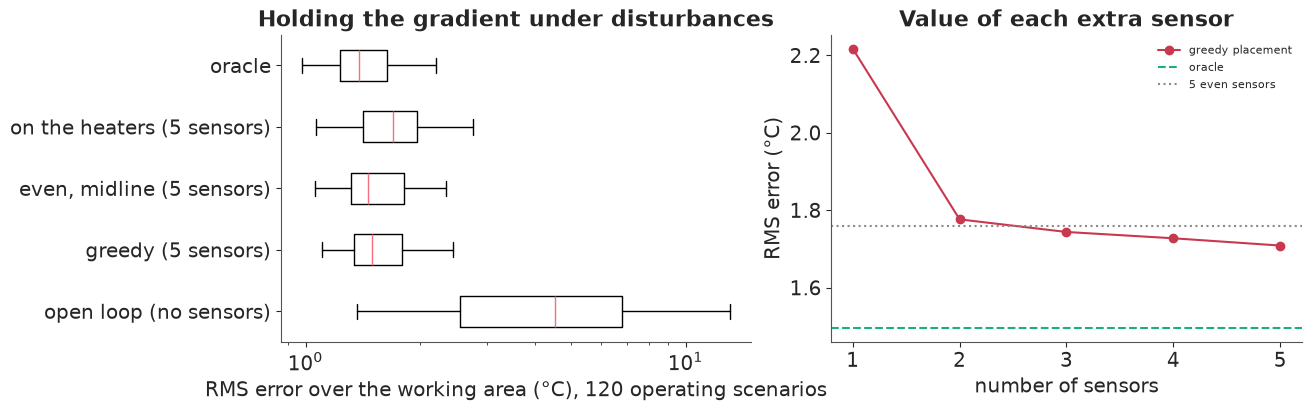

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
names = list(results)
per_scen = [np.sqrt(np.mean((results[n][:, WORK] - T_TARGET[WORK]) ** 2, axis=1)) for n in names]
ax.boxplot(per_scen, orientation="horizontal", tick_labels=names, showfliers=False)
ax.set(xlabel="RMS error over the working area (°C), 120 operating scenarios", xscale="log",
       title="Holding the gradient under disturbances")
ax = axes[1]
ax.plot(range(1, 6), sensor_path, "o-", color=RED, label="greedy placement")
ax.axhline(rms_work(oracle), color=AQUA, ls="--", label="oracle")
ax.axhline(rms_work(results["even, midline (5 sensors)"]), color=GREY, ls=":", label="5 even sensors")
ax.set(xlabel="number of sensors", ylabel="RMS error (°C)", title="Value of each extra sensor")
ax.legend(fontsize=8);

**Feedback is the big step**: from about 6.6 °C of open-loop error to 1.7 °C with five
thermocouples, and the share of operating scenarios worse than 2.5 °C falls from about 80% to
5%. **The first two sensors do almost all of it** (right panel: 2.2 °C with one, 1.8 °C with two,
then small gains), because the dominant disturbances - the room shift and the two drafts - are
low-dimensional and a couple of well-placed readings pin them down.

**Where** the sensors go matters only modestly here: the greedy layout (1.71 °C) edges out five
sensors spread evenly along the midline (1.76 °C), and sensors placed **on the heaters** are the
worst of the three (1.84 °C). A sensor at a heater mostly measures that heater's own neighbourhood,
which mixes its ageing with the local draft, and it says less about the working area. The greedy
layout spreads its sensors over the working area and the hot end. The **oracle**, which knows
every disturbance exactly, reaches 1.50 °C: the floor set by the heater layout itself. Better
sensing can close at most the last 0.2 °C; beyond that, only better heaters (or a cooler at the
cold end) help.

## 6 · The final design

final design: 6 heaters (nominal powers [ 7.2  6.1  2.1  6.3  5.8 12.4] W, total 40 W), insulation strips ['27-33 cm', '33-40 cm'], sensors at (cm) [(np.float64(24.2), np.float64(7.5)), (np.float64(17.5), np.float64(7.5)), (np.float64(37.5), np.float64(4.2)), (np.float64(20.8), np.float64(4.2)), (np.float64(20.8), np.float64(17.5))]


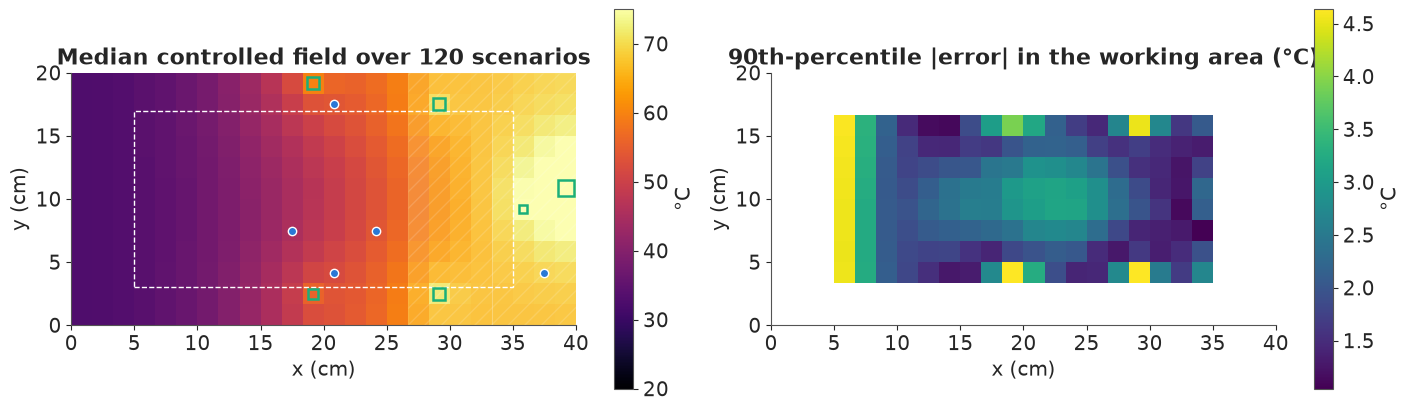

In [9]:
final = results["greedy (5 sensors)"]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
im = show_field(ax, np.median(final, axis=0), "Median controlled field over 120 scenarios")
for s_ in chosen_strips:
    ax.add_patch(Rectangle((100 * STRIPS[s_][0], 0), 100 * (STRIPS[s_][1] - STRIPS[s_][0]), 100 * LY,
                           fill=True, fc="white", alpha=0.15, ec="white", lw=0.8, hatch="//"))
for c, pw in zip(CANDIDATES[sites], p_nom):
    ax.plot(100 * xc[c % NX], 100 * yc[c // NX], "s", ms=5 + pw / 2, mfc="none", mec=AQUA, mew=1.8)
for c in chosen_sensors:
    ax.plot(100 * xc[c % NX], 100 * yc[c // NX], "o", ms=6, mfc=BLUE, mec="white")
fig.colorbar(im, ax=ax, label="°C")
ax = axes[1]
err_q = np.quantile(np.abs(final - T_TARGET), 0.9, axis=0)
err_q[~WORK] = np.nan
im = ax.imshow(err_q.reshape(NY, NX), origin="lower", extent=[0, 100 * LX, 0, 100 * LY], cmap="viridis")
ax.set(title="90th-percentile |error| in the working area (°C)", xlabel="x (cm)", ylabel="y (cm)")
fig.colorbar(im, ax=ax, label="°C")
print(f"final design: {N_HEAT} heaters (nominal powers {np.round(p_nom, 1)} W, total {p_nom.sum():.0f} W), "
      f"insulation strips {[f'{100 * STRIPS[s][0]:.0f}-{100 * STRIPS[s][1]:.0f} cm' for s in chosen_strips]}, "
      f"sensors at (cm) {[(round(100 * xc[c % NX], 1), round(100 * yc[c // NX], 1)) for c in chosen_sensors]}");

The final design: heater squares (size = nominal power), hatched back-face insulation, blue
sensor dots. The error map shows where the design is weakest across the operating scenarios:
the **cold end** of the working area (the left column, which runs warm because nothing removes
heat there) and the cells **next to the frame heaters** at the top and bottom edges, which run
hot. That points at the next improvements: a heat sink or cooled bar at the left edge, heaters
spread over longer strips instead of small patches, and edge insulation to remove the least-known
heat loss.

## Summary

- **The 2-D heat equation becomes a linear system** after a finite-volume discretisation, and the
  field is linear in heater powers: every design question reduces to influence maps and
  constrained least squares (section 1).
- **Calibrate before designing.** A small experiment fixes conductivity, face losses and heater
  efficiency as a group; the edge loss stays uncertain, and its interval even misses the truth
  (section 2).
- **Design against the posterior**: heater sites and powers chosen by expected error over
  plausible plates, with heaters kept out of the working area. Here the plug-in design happens
  to coincide, but only the posterior tells you how good the design is (section 3).
- **Insulation is passive**: a fifth less power and a little less sensitivity to drafts, but no
  answer to a changing room (section 4).
- **Feedback with two to five sensors** takes the error from about 7 °C to within 0.2 °C of the
  oracle; sensors on the heaters are the weakest choice. Leave power headroom so the controller
  can act. Some errors (the cold end) no controller of heaters alone can remove (sections 5-6).

## Try it yourself

1. **Insulate the edges.** Add edge insulation as a design option (multiply $h_e$ by 0.1 on chosen
   edges). Does it remove the corner errors of section 6, and does it make the design less
   sensitive to the poorly known edge coefficient?
2. **Design the calibration.** Choose the twelve calibration thermocouple positions (instead of
   random ones) to minimise the posterior variance of the *design's* error, not of the
   parameters. Where do they go, and how much does the final closed-loop error improve?
3. **Transient control.** Add heat capacity ($\rho c\,\delta\,\partial_t u$ on the left of the heat
   equation), step the room temperature at $t = 0$, and run the controller of section 5 every
   minute with an explicit time-stepping of the plate. How long does the gradient take to recover,
   and does the greedy sensor layout still win when the controller must act before steady state?